# Tabla

In [ ]:
import pandas as pd
url = "https://raw.githubusercontent.com/jibarrrrapedroza-cloud/Estadistica2025B/refs/heads/main/Student_Performance_new.csv"
df = pd.read_csv(url)
df = df.dropna()
df

,Unnamed: 0,etnia,nivel_educativo_de_los_padres,tipo_de_comida,curso_de_preparación_para_el_examen,porcentaje_de_matematicas,porcentaje_de_lectura,porcentaje_de_escritura,sexo
0,0,group_B,licenciatura,estandar,nada,0.72,0.72,0.74,mujer
1,1,group_C,algo_de_universidad,estandar,completado,0.69,0.90,0.88,mujer
2,2,group_B,maestria,estandar,nada,0.90,0.95,0.93,mujer
3,3,group_A,tecnico_asociado,subsidiado,nada,0.47,0.57,0.44,hombre
4,4,group_C,algo_de_universidad,estandar,nada,0.76,0.78,0.75,hombre
...,...,...,...,...,...,...,...,...,...
995,995,group_E,maestria,estandar,completado,0.88,0.99,0.95,mujer
996,996,group_C,preparatoria,subsidiado,nada,0.62,0.55,0.55,hombre
997,997,group_C,preparatoria,subsidiado,completado,0.59,0.71,0.65,mujer
998,998,group_D,algo_de_universidad,estandar,completado,0.68,0.78,0.77,mujer


# Tabla ANOVA

In [ ]:
#Jacqueline Ibarra Pedroza
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05
# H0: Todas las medias son iguales
# H1: Al menos una media es distinta

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'porcentaje_de_matematicas ~ C(etnia) + C(nivel_educativo_de_los_padres) + C(tipo_de_comida) + C(curso_de_preparación_para_el_examen) + C(porcentaje_de_matematicas) + C(porcentaje_de_lectura) + C(porcentaje_de_escritura) + C(sexo)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(etnia),1.129457e-27,4.0,7.955333e+01,1.572079e-56
C(nivel_educativo_de_los_padres),1.648259e-28,5.0,9.287610e+00,1.332319e-08
C(tipo_de_comida),1.833665e-29,1.0,5.166169e+00,2.330497e-02
C(curso_de_preparación_para_el_examen),6.408645e-31,1.0,1.805572e-01,6.710132e-01
C(porcentaje_de_matematicas),3.614342e+00,80.0,1.272881e+28,0.000000e+00
C(porcentaje_de_lectura),1.307760e+00,71.0,5.189416e+27,0.000000e+00
C(porcentaje_de_escritura),1.171170e+00,76.0,4.341651e+27,0.000000e+00
C(sexo),3.060748e-29,1.0,8.623352e+00,3.417474e-03
Residual,2.740114e-27,772.0,NaN,NaN


# Etnia

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj   lower  upper  reject
-----------------------------------------------------
group_A group_B   0.0182 0.8724 -0.0336 0.0701  False
group_A group_C   0.0283 0.4968   -0.02 0.0767  False
group_A group_D   0.0573 0.0138  0.0078 0.1068   True
group_A group_E   0.1219    0.0  0.0672 0.1766   True
group_B group_C   0.0101 0.9452 -0.0269 0.0471  False
group_B group_D   0.0391  0.044  0.0006 0.0776   True
group_B group_E   0.1037    0.0  0.0587 0.1486   True
group_C group_D    0.029  0.129 -0.0047 0.0626  False
group_C group_E   0.0936    0.0  0.0527 0.1345   True
group_D group_E   0.0646 0.0003  0.0223 0.1068   True
-----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

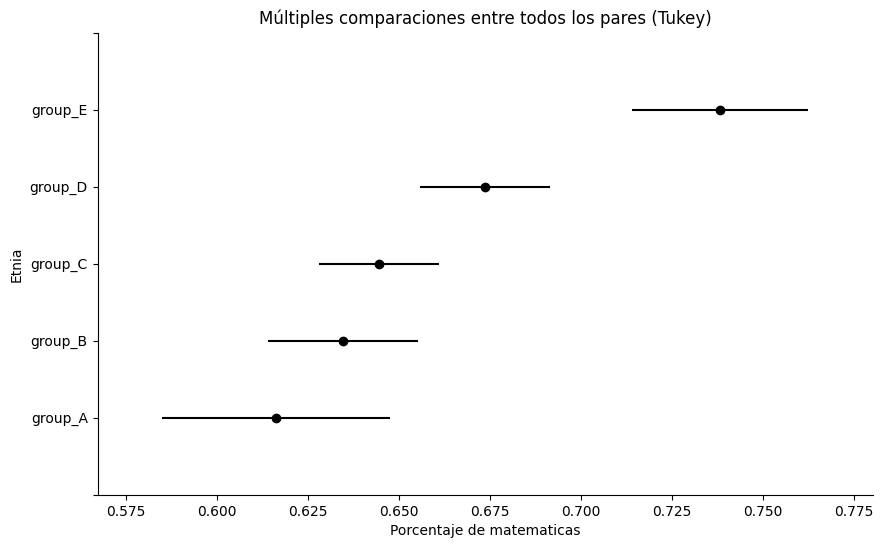

In [ ]:
#Jacqueline Ibarra Pedroza
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['porcentaje_de_matematicas'], groups=df['etnia'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Etnia", xlabel="Porcentaje de matematicas")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

De acuerdo con los resultados del ANOVA, se identifica que al menos una de las medias difiere significativamente del resto. Además, el análisis post hoc de Tukey muestra que el grupo_E destaca respecto a los demás grupos. En dicha prueba se observa que el grupo_E presenta diferencias significativas en comparación con todos los otros grupos analizados.

# Nivel educativo de los padres

              Multiple Comparison of Means - Tukey HSD, FWER=0.05              
       group1               group2       meandiff p-adj   lower   upper  reject
-------------------------------------------------------------------------------
algo_de_preparatoria algo_de_universidad   0.0363 0.1482 -0.0064   0.079  False
algo_de_preparatoria        licenciatura   0.0589 0.0119  0.0083  0.1096   True
algo_de_preparatoria            maestria   0.0625 0.0611 -0.0016  0.1266  False
algo_de_preparatoria        preparatoria  -0.0136 0.9515 -0.0577  0.0306  False
algo_de_preparatoria    tecnico_asociado   0.0439 0.0418   0.001  0.0868   True
 algo_de_universidad        licenciatura   0.0226 0.7676 -0.0259  0.0711  False
 algo_de_universidad            maestria   0.0262 0.8384 -0.0363  0.0886  False
 algo_de_universidad        preparatoria  -0.0499 0.0086 -0.0916 -0.0082   True
 algo_de_universidad    tecnico_asociado   0.0075 0.9948 -0.0328  0.0479  False
        licenciatura            maestria

Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

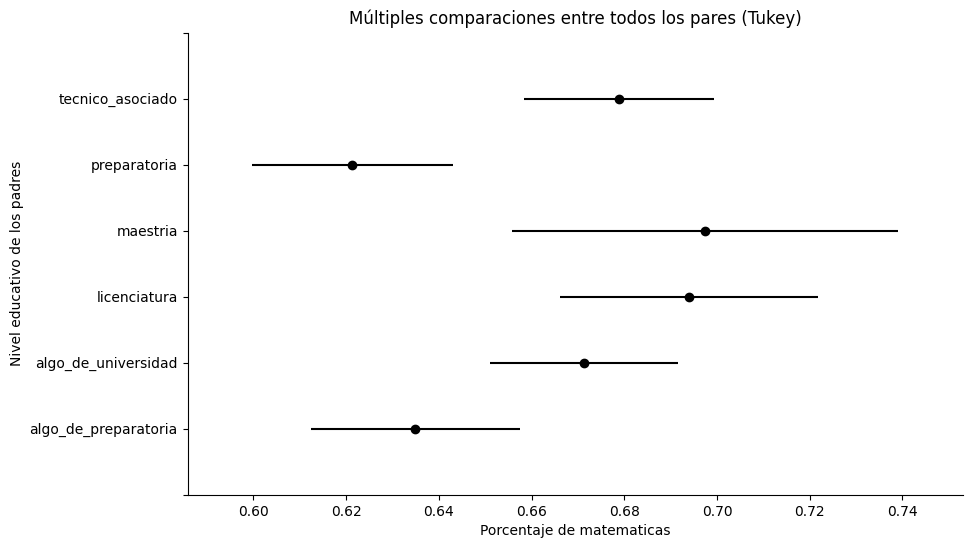

In [ ]:
#Jacqueline Ibarra Pedroza
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['porcentaje_de_matematicas'], groups=df['nivel_educativo_de_los_padres'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Nivel educativo de los padres", xlabel="Porcentaje de matematicas")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

 Una media es distinta y en Tukey observamos que los padres que contaron de tecnico para arriba en la educación si obtuvieron un intervalo de confianza mas parecido.

# Tipo de comida

   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1    group2   meandiff p-adj  lower   upper  reject
---------------------------------------------------------
estandar subsidiado  -0.1111   0.0 -0.1296 -0.0927   True
---------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

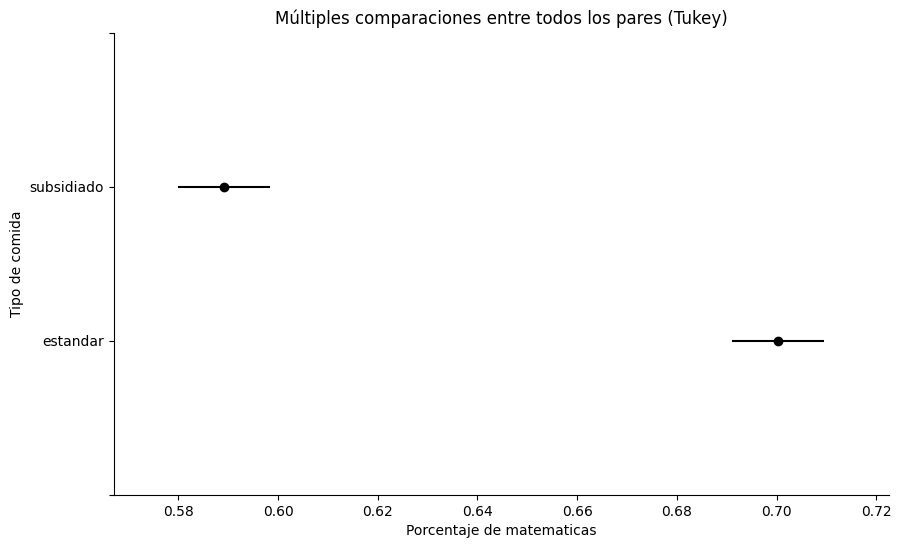

In [ ]:
#Jacqueline Ibarra Pedroza
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['porcentaje_de_matematicas'], groups=df['tipo_de_comida'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Tipo de comida", xlabel="Porcentaje de matematicas")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

 Anova nos demuestra que por lo menos una media es distinta y en Tukey logramos ver que el tipo de comida estandar se mantuvo muy por encima que el subsidiado, por lo tanto si existe diferencia significativa entre estas dos variables.

# Curso de preparación para el examen

  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
  group1   group2 meandiff p-adj  lower   upper  reject
-------------------------------------------------------
completado   nada  -0.0562   0.0 -0.0755 -0.0369   True
-------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

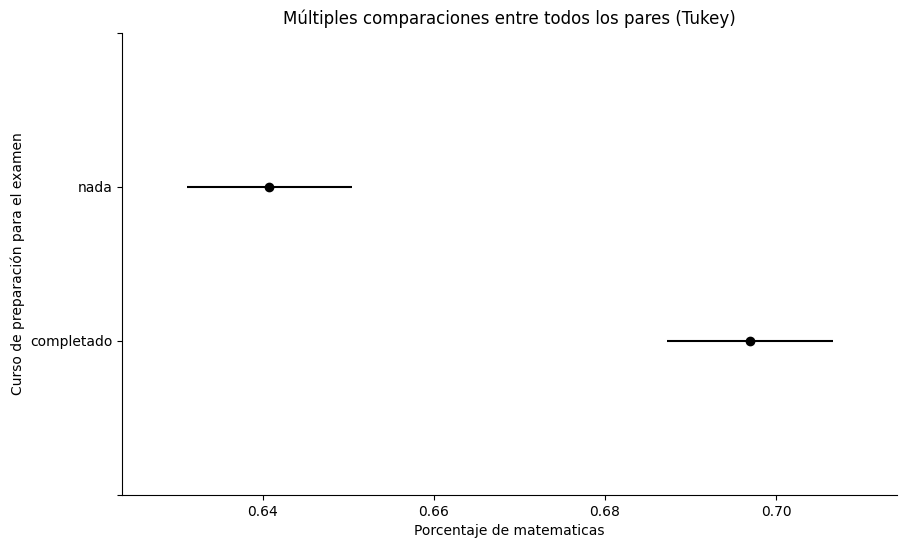

In [ ]:
#Jacqueline Ibarra Pedroza
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['porcentaje_de_matematicas'], groups=df['curso_de_preparación_para_el_examen'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Curso de preparación para el examen", xlabel="Porcentaje de matematicas")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

La tabla ANOVA indica que al menos una de las medias es diferente. Además, en la prueba de Tukey se ve claramente que las personas que tomaron el curso de preparación obtuvieron un porcentaje más alto en matemáticas, lo que confirma que sí hay una diferencia significativa entre las variables.

# Sexo

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
hombre  mujer   -0.051   0.0 -0.0695 -0.0324   True
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

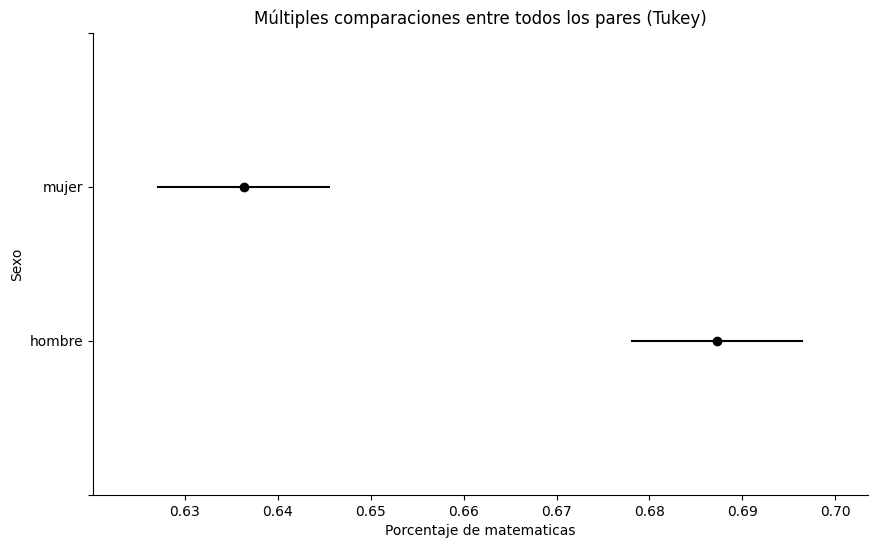

In [ ]:
#Jacqueline Ibarra Pedroza
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['porcentaje_de_matematicas'], groups=df['sexo'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Sexo", xlabel="Porcentaje de matematicas")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

La tabla ANOVA muestra que existe al menos una media diferente entre los grupos. Además, la prueba de Tukey confirma que la calificación sí cambia según el sexo. De acuerdo con los datos estadísticos de la gráfica, los hombres obtuvieron una calificación más alta que las mujeres.